## Objective

Explore the temporal structure of industrial energy consumption before training forecasting models.

The forecasting task is:
- Predict energy consumption for the next 15 min interval using only information available before that interval.

The notebook investigates:
1. Energy consumption through time;
2. Calendar and operating patterns;
3. Relationships between current usage and historical lag features;
4. Chronological train/validation/test strategy. 

No ML model is trained in this notebook. 

In [1]:
#Connecting to database
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect("Steel_energy.duckdb")

In [2]:
#Inspecting the table
con.sql("""
SELECT *
FROM gold_energy_features
LIMIT 10
""")

┌─────────────────────┬───────────┬───────┬───────┬─────────────┬─────────────┬────────────┬─────────────────┬──────────────┬──────────────┬─────────────────────────┐
│      timestamp      │ usage_kwh │ hour  │ month │ day_of_week │ week_status │ load_type  │ usage_15min_ago │ usage_1h_ago │ usage_lag_96 │ avg_usage_previous_hour │
│      timestamp      │  double   │ int64 │ int64 │   varchar   │   varchar   │  varchar   │     double      │    double    │    double    │         double          │
├─────────────────────┼───────────┼───────┼───────┼─────────────┼─────────────┼────────────┼─────────────────┼──────────────┼──────────────┼─────────────────────────┤
│ 2018-01-01 00:00:00 │      3.42 │     0 │     1 │ Monday      │ Weekday     │ Light_Load │            NULL │         NULL │         NULL │                    NULL │
│ 2018-01-01 00:15:00 │      3.17 │     0 │     1 │ Monday      │ Weekday     │ Light_Load │            3.42 │         NULL │         NULL │                    3.42 

In [3]:
#let's load it into pandas
df = con.sql("""
SELECT *
FROM gold_energy_features
ORDER BY timestamp
""").df()

In [4]:
#Let's inspect it
df.head()

,timestamp,usage_kwh,hour,month,day_of_week,week_status,load_type,usage_15min_ago,usage_1h_ago,usage_lag_96,avg_usage_previous_hour
0,2018-01-01 00:00:00,3.42,0,1,Monday,Weekday,Light_Load,NaN,NaN,NaN,NaN
1,2018-01-01 00:15:00,3.17,0,1,Monday,Weekday,Light_Load,3.42,NaN,NaN,3.4200
2,2018-01-01 00:30:00,4.00,0,1,Monday,Weekday,Light_Load,3.17,NaN,NaN,3.2950
3,2018-01-01 00:45:00,3.24,0,1,Monday,Weekday,Light_Load,4.00,NaN,NaN,3.5300
4,2018-01-01 01:00:00,3.31,1,1,Monday,Weekday,Light_Load,3.24,3.42,NaN,3.4575


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   timestamp                35040 non-null  datetime64[us]
 1   usage_kwh                35040 non-null  float64       
 2   hour                     35040 non-null  int64         
 3   month                    35040 non-null  int64         
 4   day_of_week              35040 non-null  str           
 5   week_status              35040 non-null  str           
 6   load_type                35040 non-null  str           
 7   usage_15min_ago          35039 non-null  float64       
 8   usage_1h_ago             35036 non-null  float64       
 9   usage_lag_96             34944 non-null  float64       
 10  avg_usage_previous_hour  35039 non-null  float64       
dtypes: datetime64[us](1), float64(5), int64(2), str(3)
memory usage: 3.8 MB


In [6]:
df.shape

(35040, 11)

In [7]:
#Make sure the timestamp is ordered
df = df.sort_values("timestamp").reset_index(drop=True)

In [8]:
df["timestamp"].min(), df["timestamp"].max()

(Timestamp('2018-01-01 00:00:00'), Timestamp('2018-12-31 23:45:00'))

In [9]:
df["timestamp"].is_monotonic_increasing

True

In [10]:
#For forecasting, time ordering is fundamental

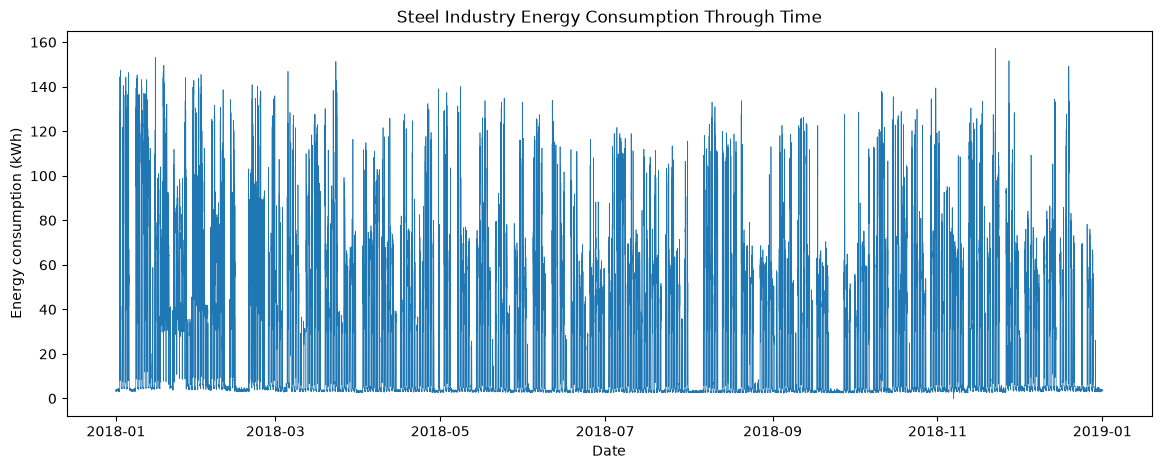

In [11]:
#Let's plot the entire series
plt.figure(figsize=(14, 5))

plt.plot(
    df["timestamp"],
    df["usage_kwh"],
    linewidth=0.5
)

plt.xlabel("Date")
plt.ylabel("Energy consumption (kWh)")
plt.title("Steel Industry Energy Consumption Through Time")
plt.show()

In [12]:
#Patterns appear repetitive
#There are short term high and low demand periods
#there are sudden transitions
#There are periods of low operation

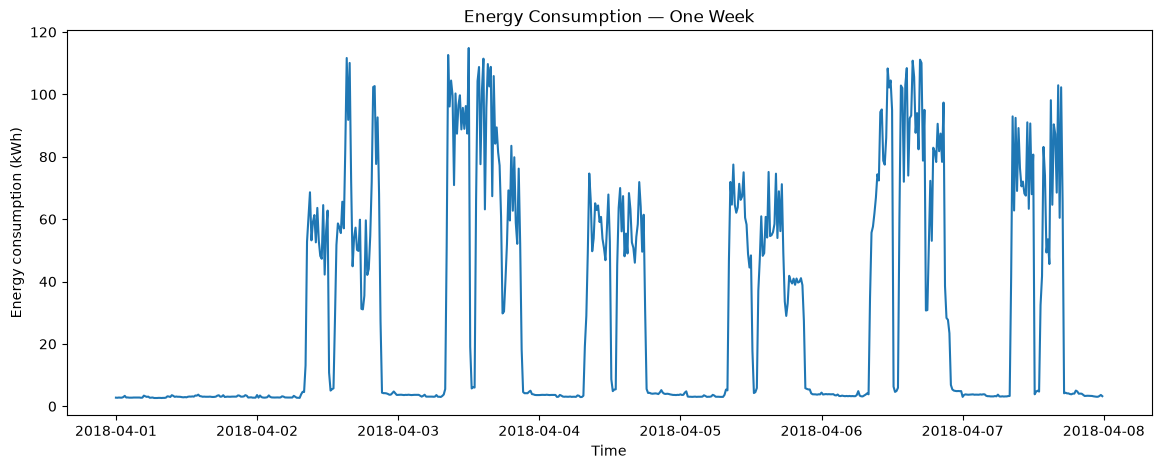

In [13]:
#Let's look at one week
week = df[
    (df["timestamp"] >= "2018-04-01") &
    (df["timestamp"] < "2018-04-08")
]

plt.figure(figsize=(14, 5))

plt.plot(
    week["timestamp"],
    week["usage_kwh"]
)

plt.xlabel("Time")
plt.ylabel("Energy consumption (kWh)")
plt.title("Energy Consumption — One Week")
plt.show()

In [14]:
#there are clear daily cycles
#there are sharp load transitions
#there are no obvious weekday/weekend differences

In [15]:
#average usage by hour
hourly_usage = (
    df.groupby("hour")["usage_kwh"]
      .mean()
)

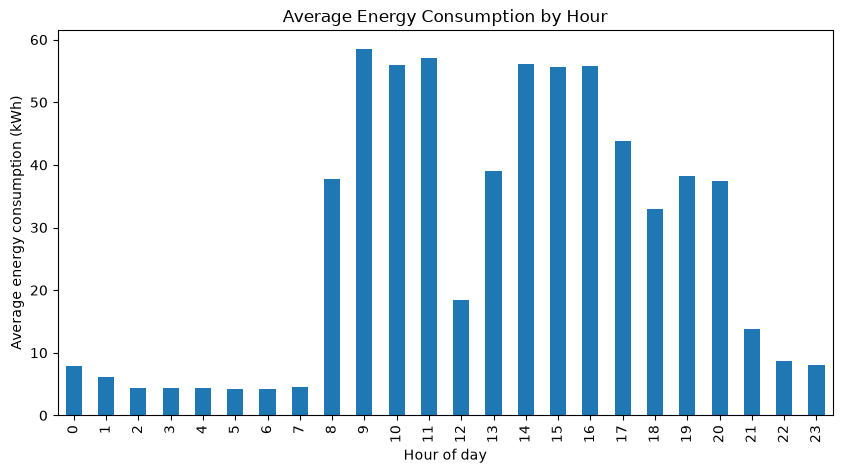

In [16]:
plt.figure(figsize=(10, 5))

hourly_usage.plot(kind="bar")

plt.xlabel("Hour of day")
plt.ylabel("Average energy consumption (kWh)")
plt.title("Average Energy Consumption by Hour")
plt.show()

In [17]:
#the bars differ strongly, time of day contains predictive information

In [18]:
#Average usage by day of week
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

In [19]:
daily_usage = (
    df.groupby("day_of_week")["usage_kwh"]
      .mean()
      .reindex(day_order)
)

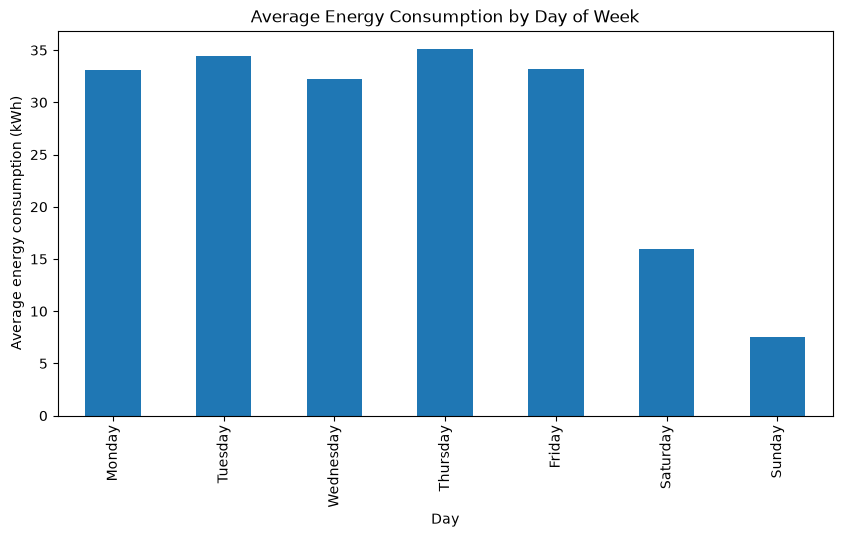

In [20]:
plt.figure(figsize=(10, 5))

daily_usage.plot(kind="bar")

plt.xlabel("Day")
plt.ylabel("Average energy consumption (kWh)")
plt.title("Average Energy Consumption by Day of Week")
plt.show()

In [21]:
#Clearly weekends behave differently from weekdays

In [22]:
#Average usage by load type
load_usage = (
    df.groupby("load_type")["usage_kwh"]
      .agg(["mean", "median", "count"])
      .sort_values("mean", ascending=False)
)

load_usage

,mean,median,count
load_type,,,
Maximum_Load,59.265314,56.630,7272
Medium_Load,38.445394,34.435,9696
Light_Load,8.626207,3.310,18072


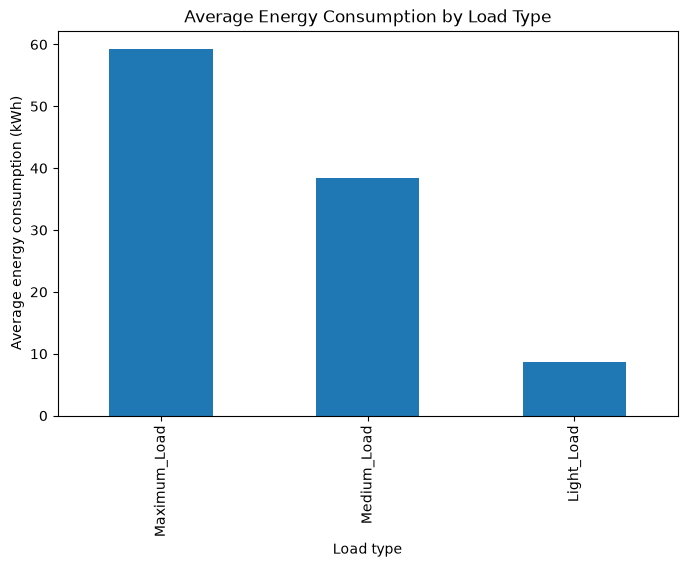

In [23]:
plt.figure(figsize=(8, 5))

load_usage["mean"].plot(kind="bar")

plt.xlabel("Load type")
plt.ylabel("Average energy consumption (kWh)")
plt.title("Average Energy Consumption by Load Type")
plt.show()

#However, load_type is only valid as predictor if the load state is known before the 15-min forecase is issued

#It looks like the day of the week, and the hour of the day have predicting information

#Historical relationships
#We investigate usage(t) vs usage(t-1), vs usage (t-4), vs usage (t-96) of the same time but of the day before

In [24]:
df["usage_lag_96"] = df["usage_kwh"].shift(96)
df["usage_lag_1"] = df["usage_kwh"].shift(1)
df["usage_lag_4"] = df["usage_kwh"].shift(4)

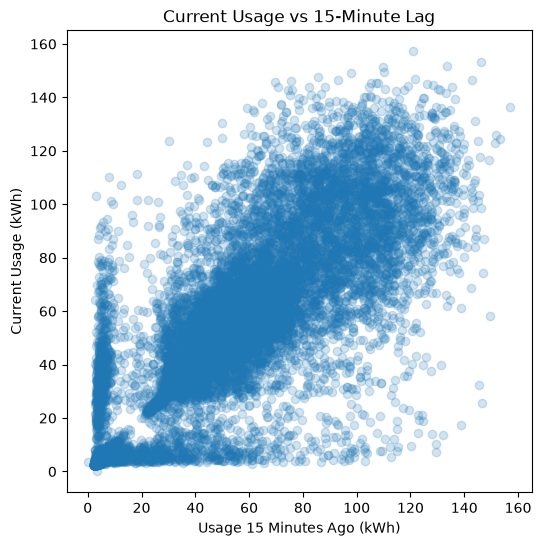

In [25]:
#Let's plot a scatter with usage(t) and its usage (t-1)
#if points in diagonal, usage (t-1) highly predictive
plt.figure(figsize=(6, 6))

plt.scatter(
    df["usage_lag_1"],
    df["usage_kwh"],
    alpha=0.2
)

plt.xlabel("Usage 15 Minutes Ago (kWh)")
plt.ylabel("Current Usage (kWh)")
plt.title("Current Usage vs 15-Minute Lag")
plt.show()

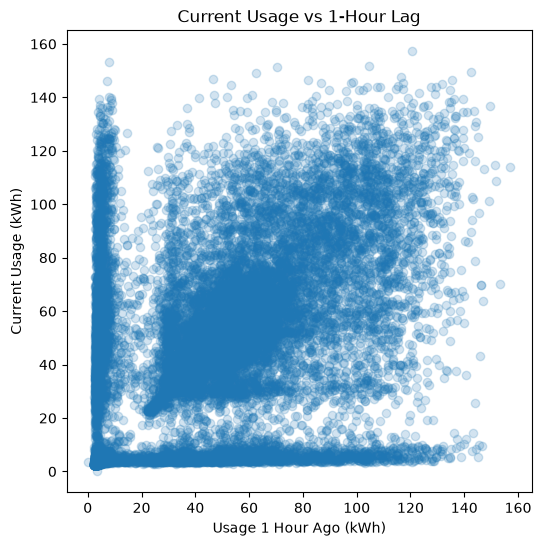

In [26]:
#Compare 1 hour lag
plt.figure(figsize=(6, 6))

plt.scatter(
    df["usage_lag_4"],
    df["usage_kwh"],
    alpha=0.2
)

plt.xlabel("Usage 1 Hour Ago (kWh)")
plt.ylabel("Current Usage (kWh)")
plt.title("Current Usage vs 1-Hour Lag")
plt.show()

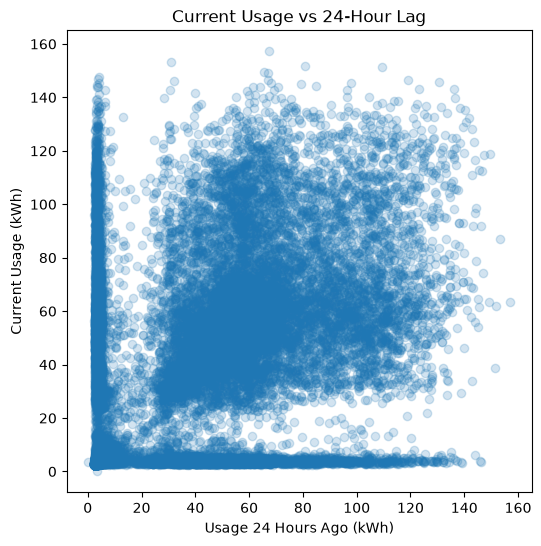

In [27]:
#compare previous day
plt.figure(figsize=(6, 6))

plt.scatter(
    df["usage_lag_96"],
    df["usage_kwh"],
    alpha=0.2
)

plt.xlabel("Usage 24 Hours Ago (kWh)")
plt.ylabel("Current Usage (kWh)")
plt.title("Current Usage vs 24-Hour Lag")
plt.show()

In [28]:
#We can calculate and quantify the relationships
df[
    [
        "usage_kwh",
        "usage_lag_1",
        "usage_lag_4",
        "usage_lag_96"
    ]
].corr()

,usage_kwh,usage_lag_1,usage_lag_4,usage_lag_96
usage_kwh,1.000000,0.911546,0.686786,0.606296
usage_lag_1,0.911546,1.000000,0.760598,0.581783
usage_lag_4,0.686786,0.760598,1.000000,0.437112
usage_lag_96,0.606296,0.581783,0.437112,1.000000


In [29]:
#It looks like the lag_1 has the highest correlation
#Using t-1 is not leakage. It's data available at the prediction time

In [30]:
#We can do this check as well with other features

In [31]:
#Now we define a validation protocol
#No random split, we use historical info to predict future energy demand

#Initial chronological split

TRAIN
January 1 → September 30

VALIDATION
October 1 → November 30

TEST
December 1 → December 31

In [32]:
#Create the split
train = df[
    df["timestamp"] < "2018-10-01"
    ].copy()

In [33]:
validation = df[
    (df["timestamp"] >= "2018-10-01") &
    (df["timestamp"] < "2018-12-01")
].copy()

In [34]:
test = df[
    df["timestamp"] >= "2018-12-01"
].copy()

In [35]:
len(train), len(validation), len(test)

(26208, 5856, 2976)

In [36]:
#We verify temporal boundaries
print(
    train["timestamp"].min(),
    train["timestamp"].max()
)

2018-01-01 00:00:00 2018-09-30 23:45:00


In [37]:
print(
    validation["timestamp"].min(),
    validation["timestamp"].max()
)

2018-10-01 00:00:00 2018-11-30 23:45:00


In [38]:
print(
    test["timestamp"].min(),
    test["timestamp"].max()
)

2018-12-01 00:00:00 2018-12-31 23:45:00


# Forecasting EDA Conclusions

## Temporal structure

- There are clear daily patterns of energy consumption;
- Higher consumption over mornings and afternoons;
- Lower consumption over weekends;

## Historical predictive information

- `Usage(t-1)` showed strong predictive information;

Historical energy demand contains strong information for predicting the next interval.

## Validation strategy

Because the intended application is future forecasting, random train/test
splitting will not be used as the primary validation strategy.

The initial chronological split is:

- Training: January–September 2018
- Validation: October–November 2018
- Test: December 2018

The test period will remain untouched during model development.

In [39]:
con.close()